# Simulations and testing

- Simulations are based on the `simulation_master.py` module. 
- All simulations are versions of AR(1) models.
- This is notebook is a guide to simulate a series, calculate GSADF, SADF and ADF test statistics, simulate critical values, compute and plot BSADF test and calculate rejection rates with simple Monte Carlo setup. 
- This notebook focuses on a simple random walk. 

Copy and paste the notebook and tweak the bubble process to get another simulation and the above calculations for it. 

First we import relevant libraries and the module file.

In [2]:
# to run R code
%load_ext rpy2.ipython

# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib

# add path to the module
sys.path.append(os.path.abspath(".."))

# import functions
from simulation import simulation_master

# reload functions
importlib.reload(simulation_master)

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <BBF229FE-E7FC-30D6-AD24-713D50386A7C> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


<module 'simulation.simulation_master' from '/Users/emilrand/Desktop/ku/Bachelor/6. semester/ba/ba_repo/simulation/simulation_master.py'>

## Random walk with drift - no bubble

### 1. First we simulate and plot $P_t$

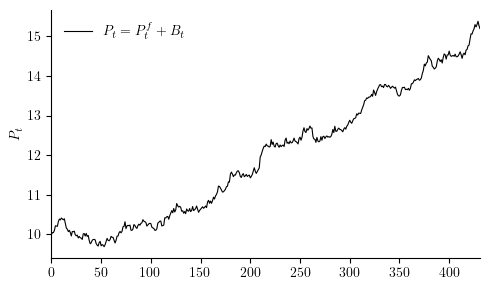

In [3]:
# simulate random walk with drift - no bubble

Pf_nobubble, B_nobubble, P_nobubble = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 432,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 0.01,
    sigma_f = 0.07,
    Pf0 = 10.0,

    include_bubble=False,

    # Random seed
    seed = 42,
    
)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_nobubble.index, P_nobubble.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_nobubble.index.min(), P_nobubble.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_nobubble.pdf')
P_nobubble = P_nobubble.rename('P_nobubble')
P_nobubble.to_csv('data/P_nobubble.csv', index=False)
plt.show()

### 2. Next we use the exuber package from R, to apply BSADF and GSADF methods to the series, and download the series. 

In [4]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_nobubble.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_nobubble)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_nobubble_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_nobubble_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  1.002501  1.475307  2.208228

  gsadf_panel
     2.208228


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



### 3. Now we plot the BSADF stats with 95 and 99% critical values. 

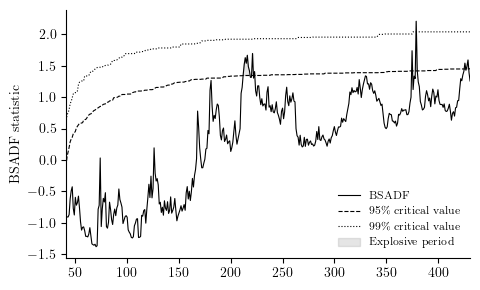

In [5]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_nobubble_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_nobubble_cv.csv")
t = P_nobubble.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_nobubble_bsadf.pdf", bbox_inches="tight")
plt.show()

### 4. Now we simulate $P_t$ 200 times and save each iteration in a new column

In [13]:
N = 200
all_series = pd.DataFrame()
seed = 5
np.random.seed(seed)

for i in range(N):
    Pf, B, P = simulation_master.simulate_price_with_bubbles(

        # Sample size
        T = 432,
        
        # Fundamental component
        rho_f = 1.0,
        mu_f = 0.005,
        sigma_f = 0.07,
        Pf0 = 10.0,

        include_bubble=False,

    )

    all_series[f"sim_{i+1}"] = P.values

all_series.to_csv("data/P_nobubble_MC.csv", index=False)

# plot all series
# plt.figure(figsize=(5, 3))
# for col in all_series.columns:
#     plt.plot(all_series.index, all_series[col], color='black', linewidth=0.5, alpha=0.3)
# plt.ylabel(r'$P_t$')
# plt.show()

/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_56039/1249597872.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_56039/1249597872.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_series[f"sim_{i+1}"] = P.values
/var/folders/z6/_5mml4hx7yb_335wjw124bph0000gq/T/ipykernel_56039/1249597872.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

### 5. Now we calculate the GSADF, SADF and ADF rejection rates for small and large sample

In [14]:
%%R
library(exuber)

# Load data
dat_full <- read.csv("data/P_nobubble_MC.csv")

# Create short sample (301–432)
dat_short <- dat_full[301:432, ]

# Sample sizes
T_full  <- nrow(dat_full)
T_short <- nrow(dat_short)

# --------------------------
# FULL SAMPLE
# --------------------------
res_full <- radf(dat_full, lag = 0)
cv_full  <- radf_mc_cv(n = T_full, nrep = 2000, seed = 123)

reject_gsadf_full <- as.numeric(res_full$gsadf)        > cv_full$gsadf_cv[2]
reject_sadf_full  <- as.numeric(res_full$sadf)         > cv_full$sadf_cv[2]
reject_adf_full   <- as.numeric(res_full$adf)          > cv_full$adf_cv[2]

rej_rate_gsadf_full <- mean(reject_gsadf_full)
rej_rate_sadf_full  <- mean(reject_sadf_full)
rej_rate_adf_full   <- mean(reject_adf_full)

# --------------------------
# SHORT SAMPLE
# --------------------------
res_short <- radf(dat_short, lag = 0)
cv_short  <- radf_mc_cv(n = T_short, nrep = 2000, seed = 123)

reject_gsadf_short <- as.numeric(res_short$gsadf)        > cv_short$gsadf_cv[2]
reject_sadf_short  <- as.numeric(res_short$sadf)         > cv_short$sadf_cv[2]
reject_adf_short   <- as.numeric(res_short$adf)          > cv_short$adf_cv[2]

rej_rate_gsadf_short <- mean(reject_gsadf_short)
rej_rate_sadf_short  <- mean(reject_sadf_short)
rej_rate_adf_short   <- mean(reject_adf_short)

# --------------------------
# OUTPUT
# --------------------------
cat("\n===== FULL SAMPLE =====\n")
cat("GSADF rejection rate:", as.numeric(rej_rate_gsadf_full), "\n")
cat("SADF  rejection rate:", as.numeric(rej_rate_sadf_full),  "\n")
cat("ADF   rejection rate:", as.numeric(rej_rate_adf_full),   "\n")

cat("\n===== SHORT SAMPLE =====\n")
cat("GSADF rejection rate:", as.numeric(rej_rate_gsadf_short), "\n")
cat("SADF  rejection rate:", as.numeric(rej_rate_sadf_short),  "\n")
cat("ADF   rejection rate:", as.numeric(rej_rate_adf_short),   "\n")


===== FULL SAMPLE =====
GSADF rejection rate: 0.145 
SADF  rejection rate: 0.135 
ADF   rejection rate: 0.165 

===== SHORT SAMPLE =====
GSADF rejection rate: 0.065 
SADF  rejection rate: 0.1 
ADF   rejection rate: 0.105 
